## 4장 k-최근접 이웃 회귀

### 1. 데이터 준비
1.1 넘파이 배열로 데이터 준비하기

In [ ]:
# 필요한 라이브러리들을 임포트한다.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
# 특성데이터인 농어의 길이를 넘파이 배열로 생성한다.
perch_length = np.array(
    [8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 
     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 
     22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 
     27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 
     36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 
     40.0, 42.0, 43.0, 43.0, 43.5, 44.0]
     )
# 타깃데이터인 농어의 무게를 넘파이 배열로 생성한다.
perch_weight = np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 
     1000.0, 1000.0]
     )

1.2 데이터를 파악하기 위해 산점도 그리기

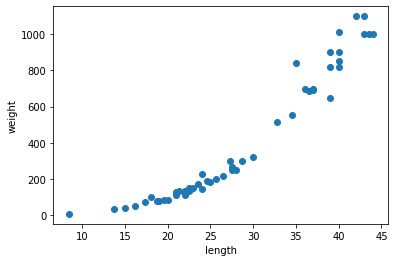

In [ ]:
# 데이터가 어떤 형태를 띠고 있는지 산점도를 그려본다.
# x축은 특성데이터, y축은 타킷데이터로 한다.
plt.scatter(perch_length, perch_weight)
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

### 2. 훈련세트와 테스트세트 준비

In [ ]:
# 사이킷런의 train_test_split()을 사용해 농어데이터를 훈련세트와 데이터세트로 나눈다.
# 동일한 결과를 얻기위해 랜덤시드 random_state=42 지정한다.
train_input, test_input, train_target, test_target = train_test_split(
    perch_length, perch_weight, random_state=42
)

In [ ]:
# 하나의 특성(길이)를 사용하기 때문에 1차원배열이다.
# 사이킷런에 사용할 훈련세트는 2차원 배열이어야 한다.
print(train_input.shape, test_input.shape)

(42,) (14,)


In [ ]:
# [기초] 넘파이의 reshape()를 이용하여 1차원 배열을 2차원 배열로 바꾼다
test_array = np.array([1,2,3,4])
print(test_array.shape)

(4,)


In [ ]:
# [기초] reshape(-1, 열)에서 -1는 배열의 크기를 자동으로 지정하는 기능이다.
# 먼저 열을 지정하고, 행을 -1로 지정하면 행의 개수가 자동 계산된다.
test_array = test_array.reshape(-1,2)
print(test_array.shape)

(2, 2)


In [ ]:
# 먼저 1열을 지정하고, 행을 -1로 지정하면 행의 개수가 자동 계산된다.
# 배열의 전체원소개수를 매번 외우지 않아도 되므로 편리하다.
train_input = train_input.reshape(-1,1)
test_input = test_input.reshape(-1,1)

In [ ]:
# 2차원 배열로 변경된 것을 확인할 수 있다.
print(train_input.shape, test_input.shape)

(42, 1) (14, 1)


### 3. 회귀 모델의 훈련과 평가

In [ ]:
# 사이킷런에서 k-최근접 이웃 회귀 알고리즘을 구현한 클래스는 KNeighborsRegressor 이다.
from sklearn.neighbors import KNeighborsRegressor

In [ ]:
# k-최근접 이웃 회귀 모델 객체를 생성한다.
knr = KNeighborsRegressor()

# fit()는 훈련세트로 모델을 훈련시킨다.
knr.fit(train_input, train_target)

KNeighborsRegressor(algorithm='auto', leaf_size=30, metric='minkowski',
                    metric_params=None, n_jobs=None, n_neighbors=5, p=2,
                    weights='uniform')

In [ ]:
# score()는 테스트세트로 모델을 평가한다.
knr.score(test_input, test_target)

0.9928094061010639

### 4. 회귀 모델의 훈련과 평가 - 또 다른 평가 방법

In [ ]:
# 사이킷런의 sklearn.metrics 패키지에서 mean_absolute_error 클래스는
# 타깃과 예측의 절댓값 오차를 평균하여 반환한다.
from sklearn.metrics import mean_absolute_error

In [ ]:
# 테스트 세트에 대한 예측을 만듭니다
test_production = knr.predict(test_input)

# 테스트 세트에 대한 평균 절댓값 오차를 계산합니다.
# 결과에서 예측이 평균적으로 19g 정도 타깃값과 다르다는 것을 알 수 있습니다.
mae = mean_absolute_error(test_target, test_production)
print(mae)

19.157142857142862


### 5. 과대적합(overfitting) vs 과소적합(underfitting)

5.1 모델이 훈련세트에 과대적합인 경우

In [ ]:
# 테스트세트의 결정계수(R2)를 다시 평가한다.
knr.score(test_input, test_target)

0.9928094061010639

In [ ]:
# 훈련세트의 결정계수를 평가한다.
# 훈련세트가 테스트세트보다 점수가 낮으니 모델이 훈련세트에 과소적합이다.
knr.score(train_input, train_target)

0.9698823289099255

5.2 과소적합 문제 해결하기 - 모델을 더 복잡하게 만든다.

In [ ]:
# 모델이 훈련세트에 과소적합 문제를 해결하기 위해서는 모델을 조금 더 복잡하게 만들면 된다.
# 이웃의 갯수를 3으로 설정합니다
knr.n_neighbors = 3

# 모델을 다시 훈련합니다.
knr.fit(train_input, train_target)

KNeighborsRegressor(algorithm='auto', leaf_size=30, metric='minkowski',
                    metric_params=None, n_jobs=None, n_neighbors=3, p=2,
                    weights='uniform')

In [ ]:
# 훈련세트의 결정계수를 평가한다.
# 훈련세트의 결정계수가 조금 더 높으므로 과소적합이 해결되었다.
knr.score(train_input, train_target)

0.9804899950518966

In [ ]:
# 테스트세트의 결정계수(R2)를 다시 평가한다.
knr.score(test_input, test_target)

0.974645996398761